Exercise

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("bhp.csv")
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [3]:
df.price_per_sqft.describe()

count    1.320000e+04
mean     7.920337e+03
std      1.067272e+05
min      2.670000e+02
25%      4.267000e+03
50%      5.438000e+03
75%      7.317000e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [4]:
min_thresold, max_thresold = df.price_per_sqft.quantile([0.001, 0.999])
min_thresold, max_thresold

(1366.184, 50959.36200000098)

In [5]:
df[df.price_per_sqft < min_thresold]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
665,Yelahanka,3 BHK,35000.0,3.0,130.0,3,371
798,other,4 Bedroom,10961.0,4.0,80.0,4,729
1867,other,3 Bedroom,52272.0,2.0,140.0,3,267
2392,other,4 Bedroom,2000.0,3.0,25.0,4,1250
3934,other,1 BHK,1500.0,1.0,19.5,1,1300
5343,other,9 BHK,42000.0,8.0,175.0,9,416
5417,Ulsoor,4 BHK,36000.0,4.0,450.0,4,1250
5597,JP Nagar,2 BHK,1100.0,1.0,15.0,2,1363
7166,Yelahanka,1 Bedroom,26136.0,1.0,150.0,1,573
7862,JP Nagar,3 BHK,20000.0,3.0,175.0,3,875


In [6]:
df[df.price_per_sqft < max_thresold]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
...,...,...,...,...,...,...,...
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689
13196,other,4 BHK,3600.0,5.0,400.00,4,11111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258
13198,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407


In [8]:
# Removing Outlier
df2 = df[(df.price_per_sqft < max_thresold) & (df.price_per_sqft > min_thresold)]
df2.shape

(13172, 7)

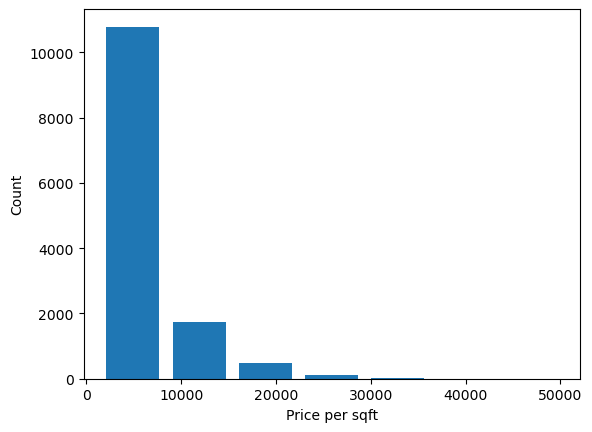

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.hist(df2.price_per_sqft, bins=7, rwidth=0.8)
plt.xlabel("Price per sqft")
plt.ylabel("Count")
plt.show()

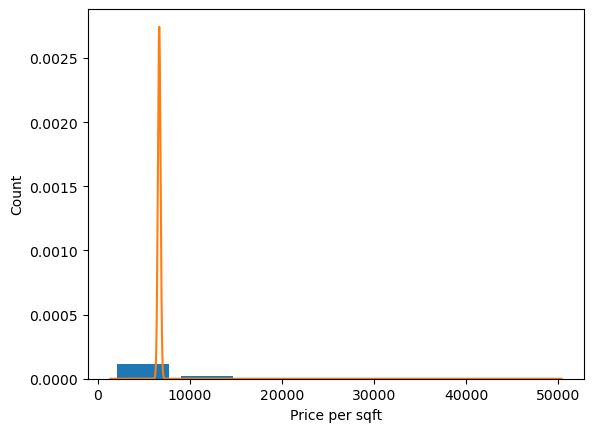

In [20]:
from scipy.stats import norm
import numpy as np
plt.hist(df2.price_per_sqft, bins=7, rwidth=0.8, density=True)
plt.xlabel("Price per sqft")
plt.ylabel("Count")

rng = np.arange(df2.price_per_sqft.min(), df2.price_per_sqft.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df2.price_per_sqft.mean(), df2.price.std()))

In [21]:
df2.price_per_sqft.mean()

6663.6537351958705

In [22]:
df.price_per_sqft.std()

106727.16032810845

(1) Outlier detection and removal using 4 standard deviation

In [31]:
upper_limit = df2.price_per_sqft.mean() + ( 4 * df2.price_per_sqft.std() )
upper_limit

23227.73653589429

In [32]:
lower_limit = df2.price_per_sqft.mean() - ( 4 * df2.price_per_sqft.std() )
lower_limit

-9900.429065502549

Here are the outliers that are beyond 4 std dev from mean

In [38]:
df2[(df2.price_per_sqft > upper_limit) | (df2.price_per_sqft < lower_limit)]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333
190,Bellandur,4 Bedroom,1200.0,5.0,325.0,4,27083
733,Cunningham Road,4 BHK,5270.0,4.0,1250.0,4,23719
760,other,9 Bedroom,600.0,9.0,190.0,9,31666
...,...,...,...,...,...,...,...
13081,other,6 Bedroom,8000.0,6.0,2800.0,6,35000
13094,other,4 Bedroom,1200.0,5.0,325.0,4,27083
13127,other,4 Bedroom,1200.0,5.0,325.0,4,27083
13185,Hulimavu,1 BHK,500.0,1.0,220.0,1,44000


Now remove these outliers and generate new dataframe

In [41]:
df_no_outlier = df2[(df2.price_per_sqft < upper_limit) & (df2.price_per_sqft > lower_limit)]
df_no_outlier.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [42]:
df_no_outlier.shape

(13047, 7)

In [43]:
df.shape

(13200, 7)

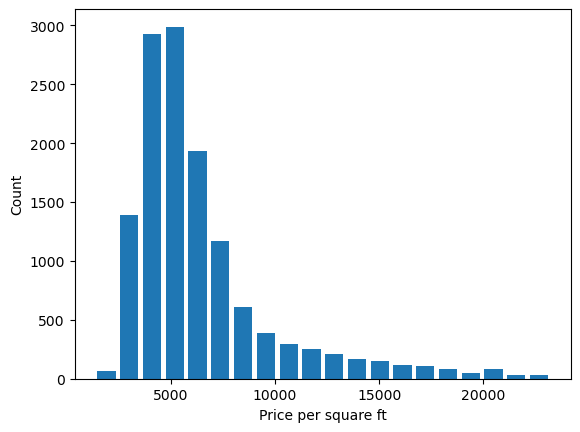

In [44]:
plt.hist(df_no_outlier.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel('Price per square ft')
plt.ylabel('Count')
plt.show()

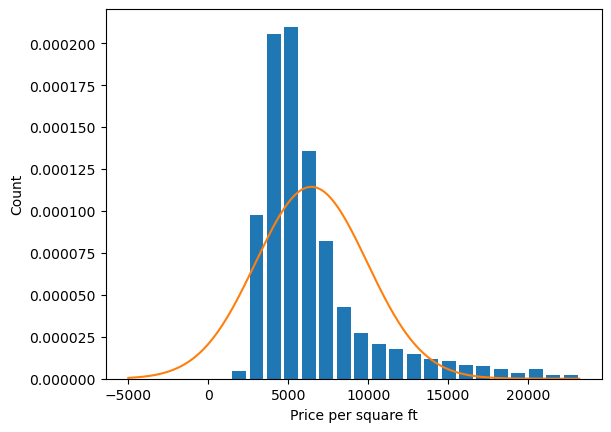

In [46]:
from scipy.stats import norm
import numpy as np
plt.hist(df_no_outlier.price_per_sqft, bins=20, rwidth=0.8, density=True)
plt.xlabel('Price per square ft')
plt.ylabel('Count')

rng = np.arange(-5000, df_no_outlier.price_per_sqft.max(), 100)
plt.plot(rng, norm.pdf(rng,df_no_outlier.price_per_sqft.mean(),df_no_outlier.price_per_sqft.std()))